In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, fbeta_score, precision_score, recall_score

X_test = pd.read_csv("Preprocessed_Data/X_test.csv")
y_test = pd.read_csv("Preprocessed_Data/y_test.csv").squeeze()
X_train = pd.read_csv("Preprocessed_Data/X_train.csv")
y_train = pd.read_csv("Preprocessed_Data/y_train.csv").squeeze()
X_valid = pd.read_csv("Preprocessed_Data/X_validation.csv")
y_valid = pd.read_csv("Preprocessed_Data/y_validation.csv").squeeze()

In [142]:
tree = DecisionTreeClassifier(random_state = 0)
tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [143]:
y_valid_tree = tree.predict(X_valid)
print("Validation accuracy: ", accuracy_score(y_valid, y_valid_tree))
print("Confusion matrix: ")
print(confusion_matrix(y_valid, y_valid_tree))
print("classification report: ")
print(classification_report(y_valid, y_valid_tree))

Validation accuracy:  0.7663043478260869
Confusion matrix: 
[[65 17]
 [26 76]]
classification report: 
              precision    recall  f1-score   support

           0       0.71      0.79      0.75        82
           1       0.82      0.75      0.78       102

    accuracy                           0.77       184
   macro avg       0.77      0.77      0.77       184
weighted avg       0.77      0.77      0.77       184



In [144]:
max_depth = [2, 3, 4, 5, 6, 7, 8]
min_split = [2, 3, 5, 10, 20]
min_leaf = [1, 2, 3, 4, 5, 6, 7, 8]
best_f2 = 0
for depth in max_depth: 
    for minspl in min_split:
        for minl in min_leaf:
            tree = DecisionTreeClassifier(max_depth = depth, min_samples_split = minspl, min_samples_leaf = minl, random_state = 0)
            tree.fit(X_train, y_train)
            y_valid_pred = tree.predict(X_valid)
            f2 = fbeta_score(y_valid, y_valid_pred, beta = 2)
            if f2 > best_f2:
                best_f2 = f2 
                best_tree = tree 
                tree_param = {"max_depth": depth, "min_samples_split":minspl, "min_samples_leaf": minl}
print("Best parameters: ", tree_param)
print("Best F2: ", best_f2)

Best parameters:  {'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 1}
Best F2:  0.8897485493230174


In [145]:
y_valid_pred_best = best_tree.predict(X_valid)
print("New validation accuracy: ", accuracy_score(y_valid, y_valid_pred_best))
print("Confusion matrix: ")
print(confusion_matrix(y_valid, y_valid_pred_best))
print("Classification report: ")
print(classification_report(y_valid, y_valid_pred_best))

New validation accuracy:  0.8532608695652174
Confusion matrix: 
[[65 17]
 [10 92]]
Classification report: 
              precision    recall  f1-score   support

           0       0.87      0.79      0.83        82
           1       0.84      0.90      0.87       102

    accuracy                           0.85       184
   macro avg       0.86      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



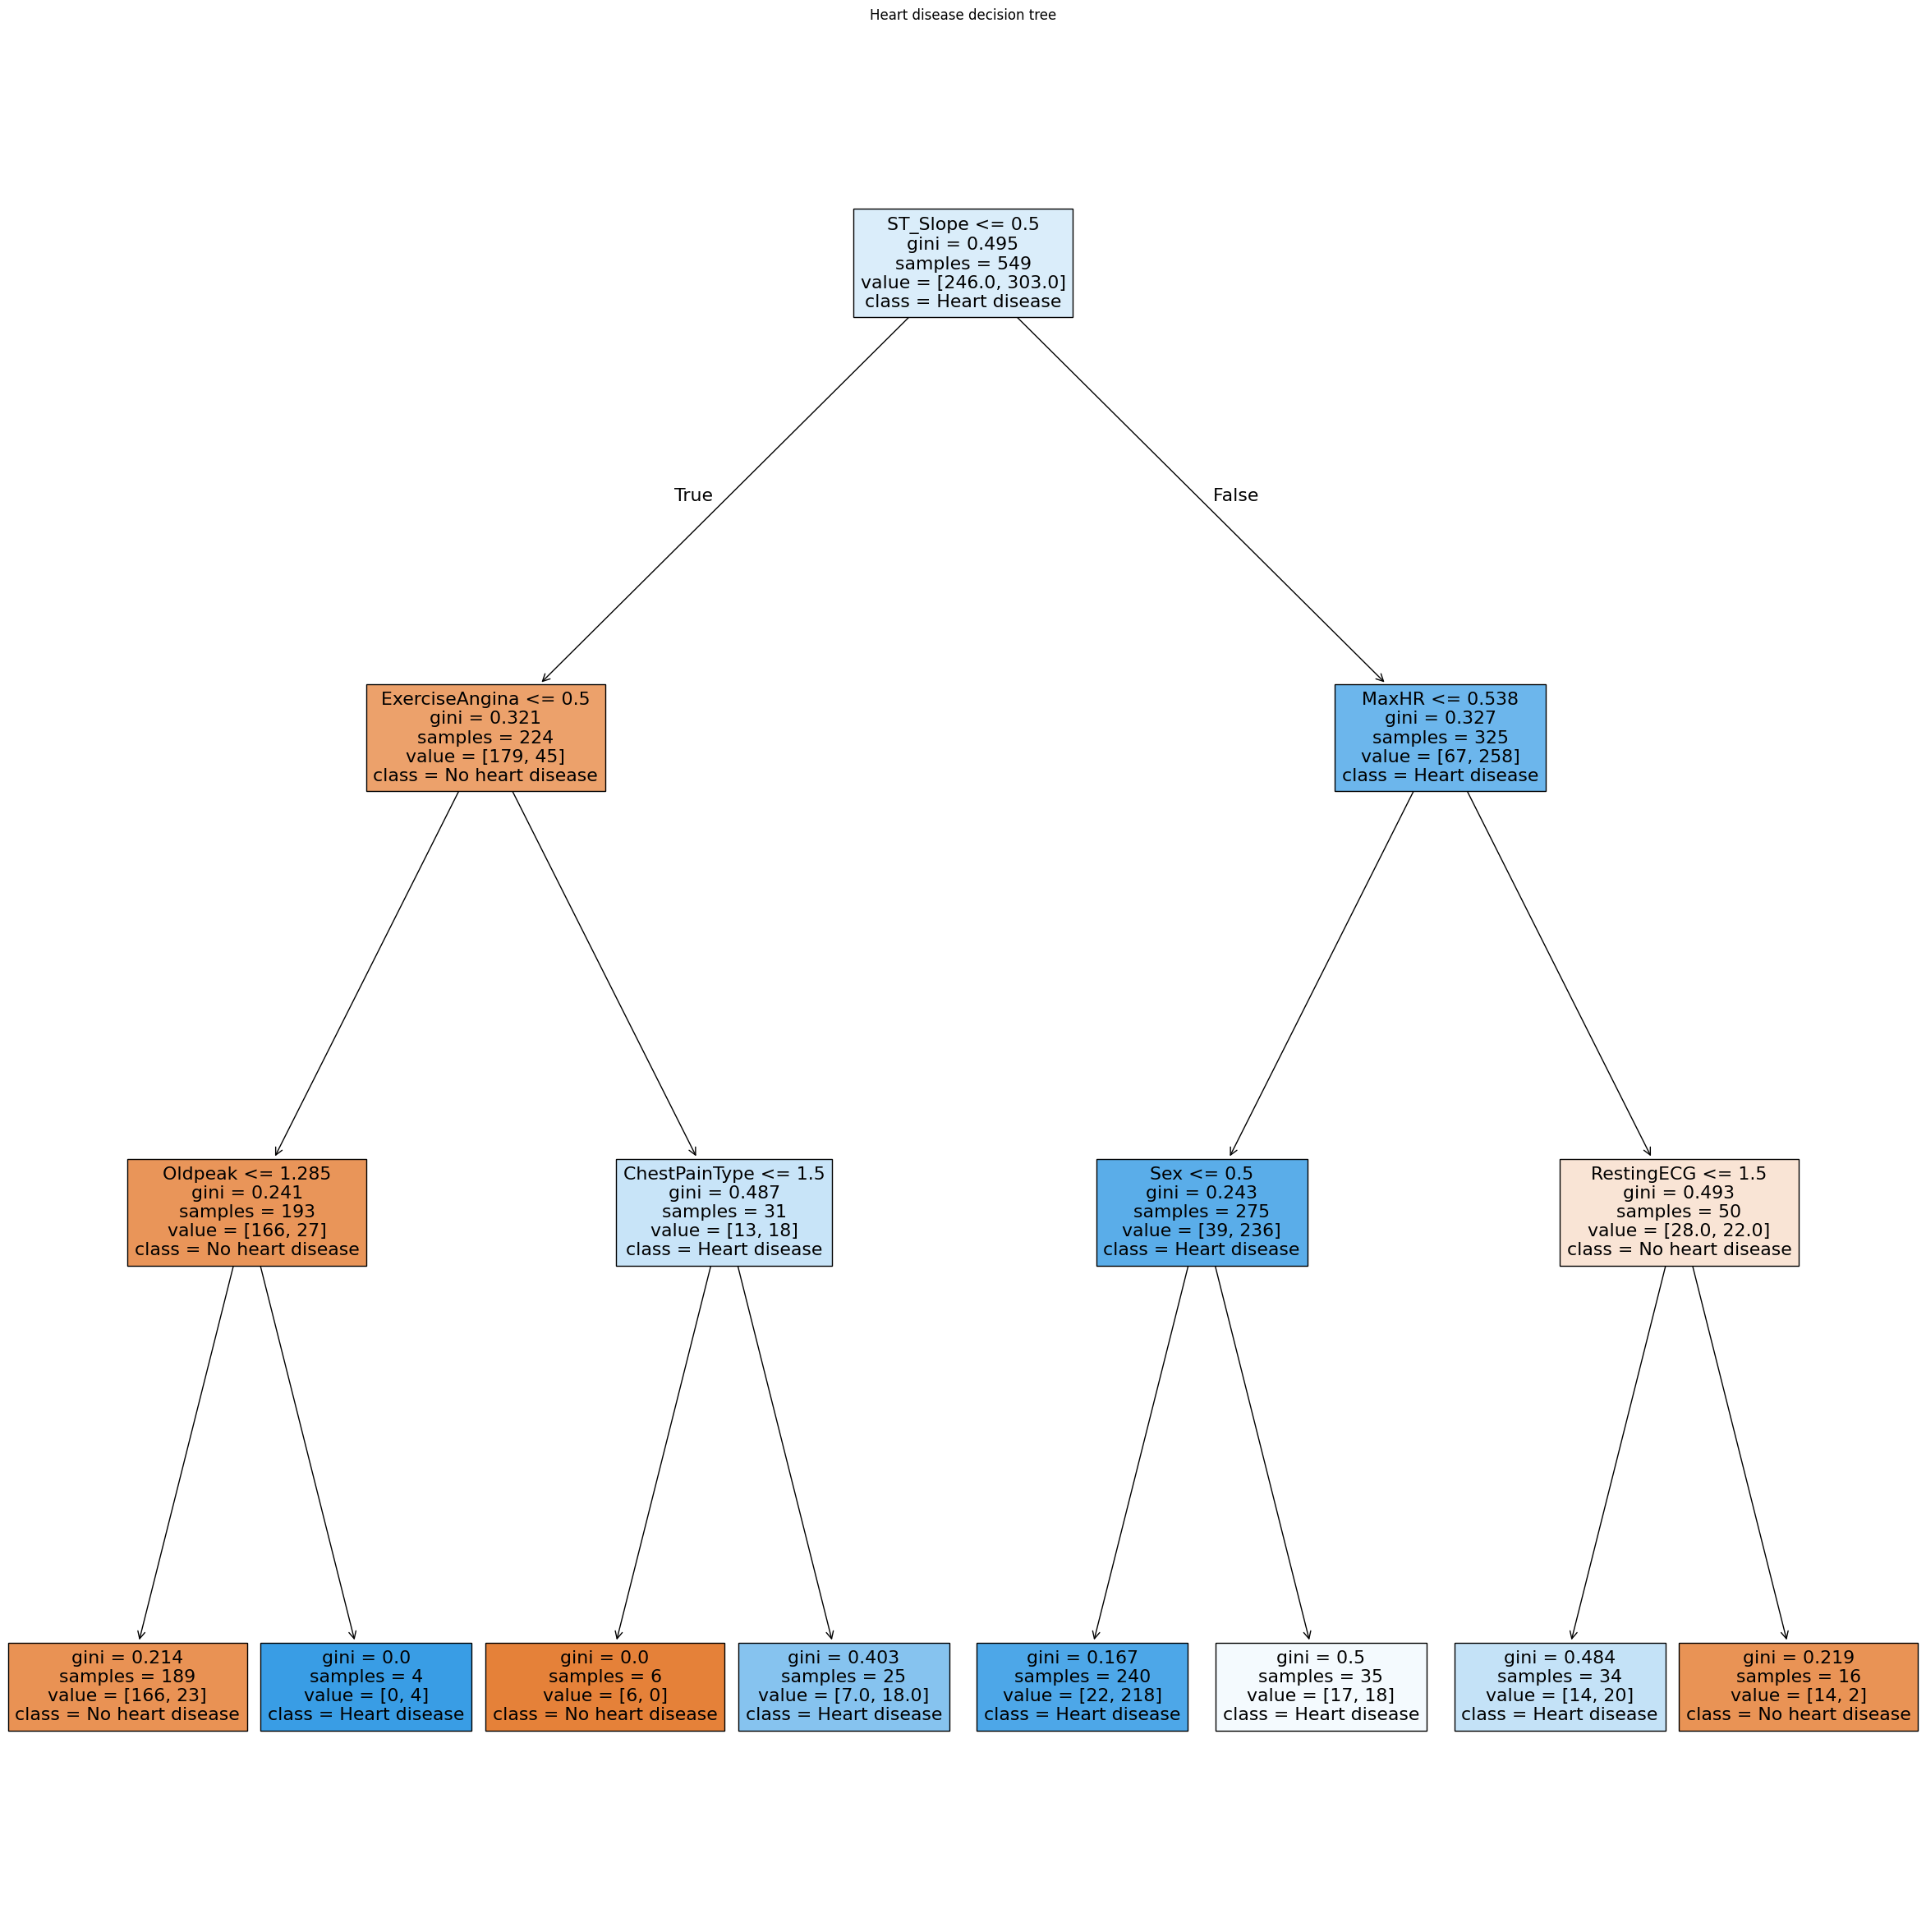

In [146]:
plt.figure(figsize = (30, 30))
plot_tree(best_tree, feature_names = X_train.columns, class_names = ["No heart disease", "Heart disease"], filled = True)
plt.title("Heart disease decision tree")
plt.show()

In [147]:
y_test_tree = best_tree.predict(X_test)
print("Test accuracy with new tree parameters:", accuracy_score(y_test, y_test_tree))
print(" ")
print("Confusion matrix: ")
print(confusion_matrix(y_test, y_test_tree))
print(" ")
print("Classification report: ")
print(classification_report(y_test, y_test_tree))

Test accuracy with new tree parameters: 0.8315217391304348
 
Confusion matrix: 
[[68 14]
 [17 85]]
 
Classification report: 
              precision    recall  f1-score   support

           0       0.80      0.83      0.81        82
           1       0.86      0.83      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.83      0.83       184
weighted avg       0.83      0.83      0.83       184



In [148]:
forest = RandomForestClassifier(random_state = 0)
forest.fit(X_train, y_train)

y_valid_forest = forest.predict(X_valid)
print("Validation accuracy of the forest: ", accuracy_score(y_valid, y_valid_forest))
print(" ")
print("confusion_matrix: ")
print(confusion_matrix(y_valid, y_valid_forest))
print(" ")
print("classification_report: ")
print(classification_report(y_valid, y_valid_forest))

Validation accuracy of the forest:  0.842391304347826
 
confusion_matrix: 
[[68 14]
 [15 87]]
 
classification_report: 
              precision    recall  f1-score   support

           0       0.82      0.83      0.82        82
           1       0.86      0.85      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



In [ ]:
n_estim = [50, 100, 200]
max_depth = [3, 5, 7, 10]
min_split = [2, 5, 10]
min_leaf = [1, 2, 4]
class_weight = [None, "balanced"]
best_f2 = 0

for n in n_estim:
    for depth in max_depth:
        for minspl in min_split:
            for minl in min_leaf:
                for classw in class_weight:
                    forest = RandomForestClassifier(n_estimators = n, max_depth = depth, min_samples_split = minspl, min_samples_leaf = minl, class_weight = classw, random_state = 0)
                    forest.fit(X_train, y_train)
                    y_valid_pred = forest.predict(X_valid)
                    f2 = fbeta_score(y_valid, y_valid_pred, beta = 2)
                    if f2 > best_f2:
                        best_f2 = f2
                        best_forest = forest 
                        best_params = {"n_estimators":n, "max_depth": depth, "min_samples_split": minspl, "min_samples_leaf": minl, "class_weight": classw}
print("Best random forest parameters: ", best_params)
print("Best random forest f2: ", best_f2)

In [ ]:
y_valid_pred_best = best_forest.predict(X_valid)
print("Best random forest validation accuracy: ", accuracy_score(y_valid, y_valid_pred_best))
print(" ")
print("Confusion matrix: ")
print(confusion_matrix(y_valid, y_valid_pred_best))
print(" ")
print("Classification report: ")
print(classification_report(y_valid, y_valid_pred_best))

Best random forest validation accuracy:  0.8913043478260869
 
Confusion matrix: 
[[71 11]
 [ 9 93]]
 
Classification report: 
              precision    recall  f1-score   support

           0       0.89      0.87      0.88        82
           1       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



In [ ]:
y_valid_proba = best_forest.predict_proba(X_valid)[:, 1]
thresh = np.arange(0.1, 1, 0.01)
scores = []

for tr in thresh:
    y_valid_thresh = (y_valid_proba >= tr).astype(int)
    f2 = fbeta_score(y_valid, y_valid_thresh, beta = 2)
    recall = recall_score(y_valid, y_valid_thresh)
    precision = precision_score(y_valid, y_valid_thresh)
    scores.append((tr, f2, recall, precision))
best_thresh, best_f2, best_recall, best_precision = max(scores, key = lambda x: x[1])

print("Best threshold: ", best_thresh)
print("Best F2: ", best_f2)
print("Recall: ", best_recall)
print("Precision: ", best_precision)

Best threshold:  0.3699999999999999
Best F2:  0.9333333333333333
Recall:  0.9607843137254902
Precision:  0.8376068376068376


In [ ]:
y_valid_forest_thresh = (y_valid_proba >= best_thresh).astype(int)
print("Random forest validation accuracy with tuned threshold: ", accuracy_score(y_valid, y_valid_forest_thresh))
print(" ")
print("Confusion matrix: ")
print(confusion_matrix(y_valid, y_valid_forest_thresh))
print(" ")
print("Classification report: ")
print(classification_report(y_valid, y_valid_forest_thresh))

Random forest validation accuracy with tuned threshold:  0.875
 
Confusion matrix: 
[[63 19]
 [ 4 98]]
 
Classification report: 
              precision    recall  f1-score   support

           0       0.94      0.77      0.85        82
           1       0.84      0.96      0.89       102

    accuracy                           0.88       184
   macro avg       0.89      0.86      0.87       184
weighted avg       0.88      0.88      0.87       184



In [ ]:
y_test_proba = best_forest.predict_proba(X_test)[:, 1]
y_test_pred_thresh = (y_test_proba >= best_thresh).astype(int)

print("Random forest test accuracy: ", accuracy_score(y_test, y_test_pred_thresh))
print(" ")
print("Best parameters: ", best_params)
print(" ")
print("Best threshold: ", best_thresh)
print(" ")
print("Confusion matrix: ")
print(confusion_matrix(y_test, y_test_pred_thresh))
print(" ")
print("Classification report: ")
print(classification_report(y_test, y_test_pred_thresh))

Random forest test accuracy:  0.8478260869565217
 
Best parameters:  {'n_estimators': 200, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 4, 'class_weight': None}
 
Best threshold:  0.3699999999999999
 
Confusion matrix: 
[[62 20]
 [ 8 94]]
 
Classification report: 
              precision    recall  f1-score   support

           0       0.89      0.76      0.82        82
           1       0.82      0.92      0.87       102

    accuracy                           0.85       184
   macro avg       0.86      0.84      0.84       184
weighted avg       0.85      0.85      0.85       184

